In [6]:
import sys
import os

sys.path.append(os.path.abspath('..'))

In [7]:
import random, math
import numpy as np
import matplotlib.pyplot as plt

from src.circuits import random_brickwork_circuit
from src.entanglement import log_negativity
from src.simulation import process_p

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, random_clifford, negativity, DensityMatrix, partial_trace
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
 
from qiskit_aer.noise import NoiseModel, depolarizing_error

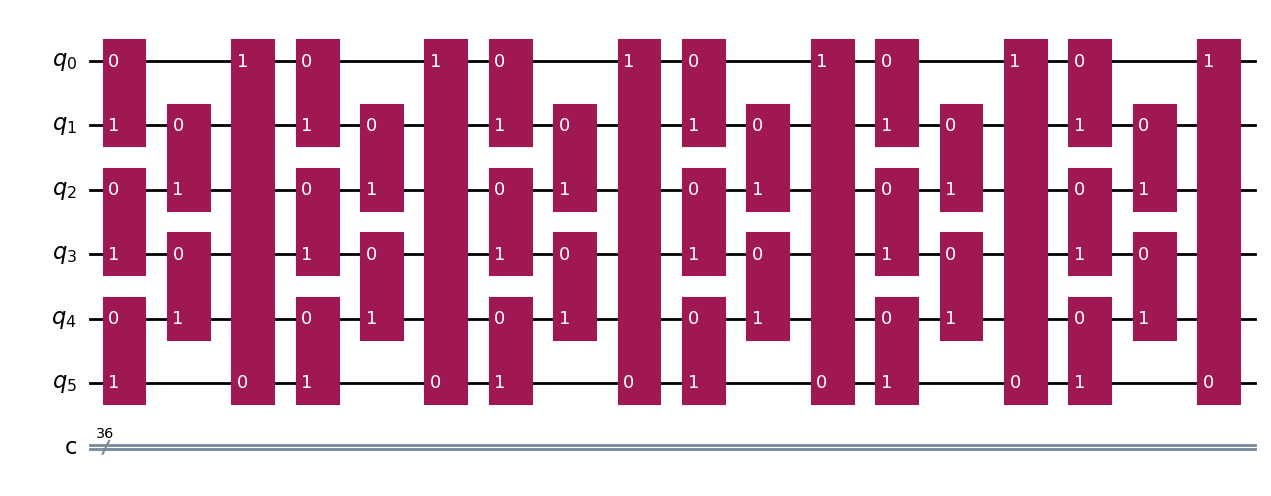

In [9]:
# Depolarizing channel function

def random_depolarizing_channel(L):
    for i in range(L):
            depolarizingchannel = random_clifford(1, seed=None)
            circuit.unitary(depolarizingchannel, [i], label="dp")
        
# Clifford gate random brickwork circuit function

def random_brickwork_circuit(L):
    global circuit
    circuit = QuantumCircuit(L, L**2)

    for t in range(L*2):
        if t % 2 == 0:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                circuit.unitary(gate, [2*i, 2*i+1], label=" ")
        else:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                if 2*i == L-2:
                    circuit.unitary(gate, [L-1, 0], label=" ")
                else:
                    circuit.unitary(gate, [2*i+1, 2*i+2], label=" ")

    # circuit.measure_all()
    return circuit

# Logarithmic Negativity Function

def calculate_log_negativity(dm, subsystem):
    rho = DensityMatrix(dm)
    negv = negativity(rho, subsystem)
    log_negv = math.log(2 * negv + 1, 2)
    return log_negv

# Create circuit

random_brickwork_circuit(6)

# Draw circuit

circuit.draw("mpl")